N=64, t=3.141592653589793, K0=6, sigma=2.0
reference k0 (psi1) = (0, 1), |b_k0| = 1.453e-01
reference k0 (psi2) = (0, 0), |b_k0| = 8.155e-01
rel L2 error (rho): shadow vs baseline(low-pass)  = 8.338e-16
rel L2 error (rho): shadow vs baseline(full)      = 1.443e-02
rel L2 error (omg): shadow vs baseline(low-pass)  = 1.996e-15
rel L2 error (omg): shadow vs baseline(full)      = 1.382e-01
rel L2 error (|J|): shadow vs baseline(low-pass)  = 1.962e-15
rel L2 error (|J|): shadow vs baseline(full)      = 1.050e-01


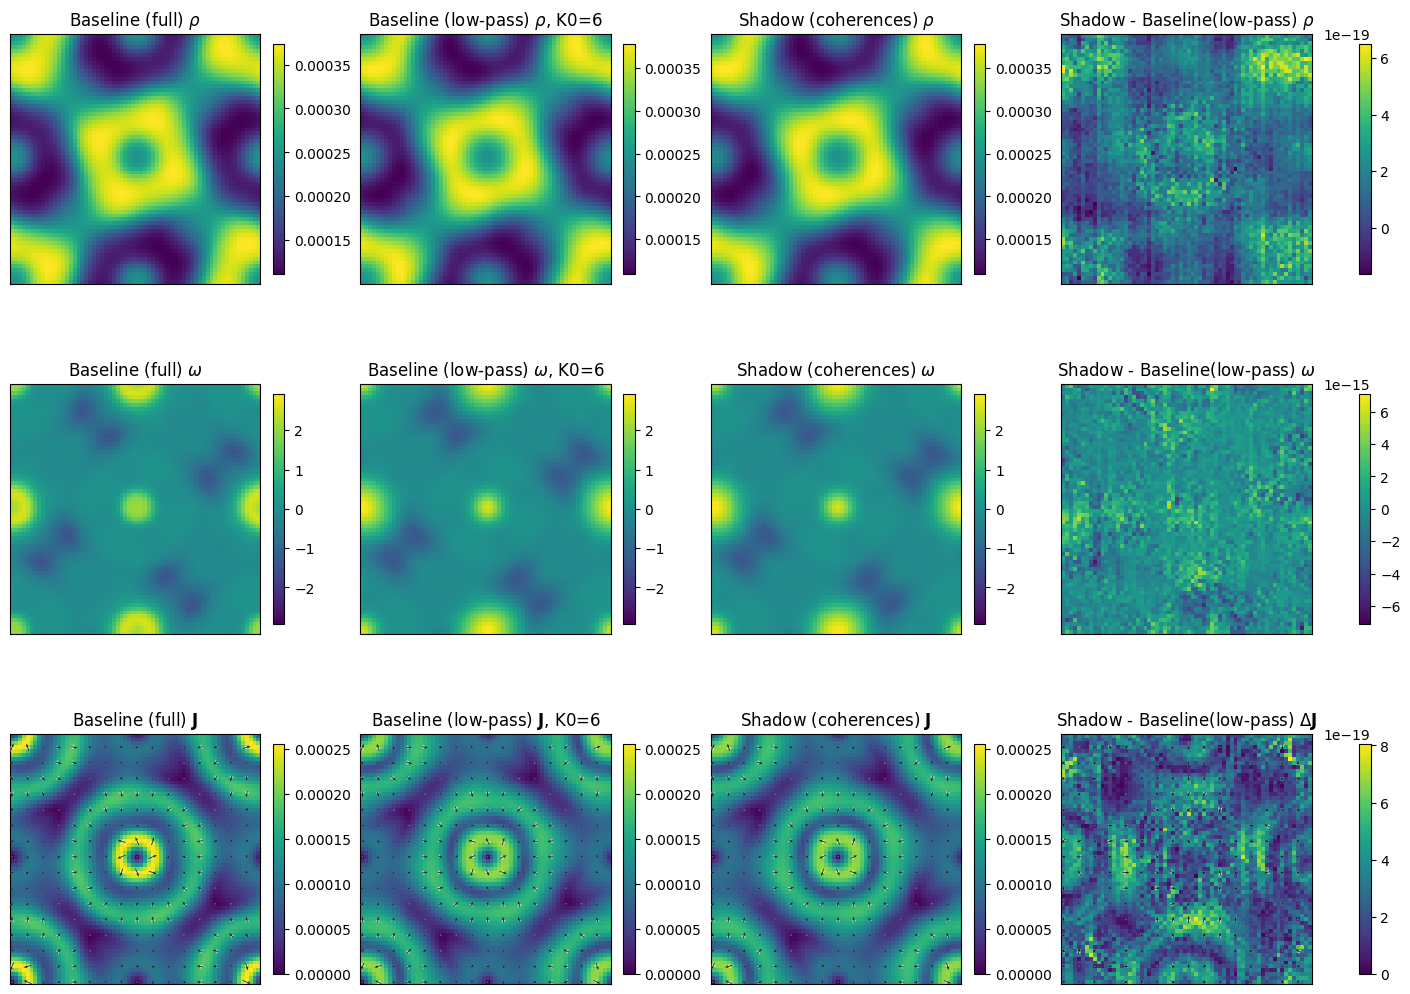

In [9]:
"""
shadow_test_v4.py

Based on shadow_test_v3.py.

Adds momentum visualizations (vector current J) in addition to density (rho) and vorticity (omega).

Figure layout (3 rows x 4 cols):
  Row 1: Density rho
    (1) Baseline (full) rho
    (2) Baseline (low-pass) rho
    (3) Shadow (coherences) rho
    (4) Shadow - Baseline(low-pass) rho

  Row 2: Vorticity omega
    (1) Baseline (full) omega
    (2) Baseline (low-pass) omega
    (3) Shadow (coherences) omega
    (4) Shadow - Baseline(low-pass) omega

  Row 3: Momentum J (vector)
    (1) Baseline (full) J
    (2) Baseline (low-pass) J
    (3) Shadow (coherences) J
    (4) Shadow - Baseline(low-pass) J

Notes:
- We use units hbar=m=1. The probability current is
    J = Im(psi* grad psi)  (sum over both components)
  which is also the momentum density when m=1.
- We visualize J as a quiver (vector arrows) over a grayscale background showing |J|.
"""

from __future__ import annotations

import math
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Qiskit imports (required)
# ----------------------------
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.circuit.library import QFT


# ============================================================
# 1) Baseline circuit pieces from circuit_2D.py
# ============================================================


def kinetic_operator(n: int, dt: float) -> QuantumCircuit:
    """Same kinetic operator as in circuit_2D.py."""
    qc = QuantumCircuit(n)
    qc.rz(-2 ** (n - 1) * dt, n - 1)
    for i in range(n):
        qc.rz(2 ** (n - i - 2) * dt, n - i - 1)
    for i in range(1, n):
        qc.cx(n - 1, n - i - 1)
        qc.rz(-2 ** (2 * n - i - 2) * dt, n - i - 1)
        qc.cx(n - 1, n - i - 1)
    for i in range(n):
        for j in range(n):
            if i != j:
                qc.cx(n - i - 1, n - j - 1)
                qc.rz(2 ** (2 * n - i - j - 4) * dt, n - j - 1)
                qc.cx(n - i - 1, n - j - 1)
    return qc


def evolve_statevector_v0(nx: int, ny: int, t: float, initial_state: np.ndarray) -> np.ndarray:
    """
    Baseline full-state evolution for V=0 using qiskit:
      initialize -> QFTx QFTy -> kinetic phase -> iQFTx iQFTy
    Returns the full final statevector (length 2^(nx+ny+1)).
    """
    q_num = nx + ny + 1
    circ = QuantumCircuit(q_num)

    # Initialize full state (2 components stacked: sigma is the MSB qubit)
    circ.initialize(initial_state)
    circ.barrier()

    # QFT on x and y registers
    circ.append(QFT(nx), range(nx))
    circ.append(QFT(ny), range(nx, nx + ny))
    circ.barrier()

    # kinetic phases (free evolution)
    circ.append(kinetic_operator(nx, t), range(nx))
    circ.append(kinetic_operator(ny, t), range(nx, nx + ny))
    circ.barrier()

    # inverse QFT back to position basis
    circ.append(QFT(nx).inverse(), range(nx))
    circ.append(QFT(ny).inverse(), range(nx, nx + ny))

    circ.save_state()

    simulator = AerSimulator(method="statevector")
    circ = transpile(circ, simulator)
    result = simulator.run(circ).result()
    sv = np.asarray(result.data(0)["statevector"], dtype=np.complex128)
    return sv


# ============================================================
# 2) Vortex initial condition (same as circuit_2D.py)
# ============================================================


def vortex_initial_condition(N: int, sigma: float = 3.0) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Returns (psi1_0, psi2_0, initial_state_vector) where:
    - psi1_0, psi2_0 have shape (N,N)
    - initial_state_vector has length 2*N*N (psi1 flattened then psi2 flattened), normalized
    """
    pi = np.pi
    x = np.linspace(-pi, pi, N, endpoint=False)
    y = np.linspace(-pi, pi, N, endpoint=False)
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    f = np.exp(-(R / sigma) ** 4)
    u = 2 * (X + 1j * Y) * f / (1 + R**2)
    v = 1j * (R**2 + 1 - 2 * f) / (1 + R**2)

    psi1 = u / np.sqrt(np.abs(u) ** 2 + np.abs(v) ** 4)
    psi2 = v**2 / np.sqrt(np.abs(u) ** 2 + np.abs(v) ** 4)

    # Quantum-state global normalization (and sync back to psi1/psi2)
    stacked = np.array([psi1, psi2]).reshape(-1).astype(np.complex128)
    stacked /= np.linalg.norm(stacked)

    psi1_n = stacked[: N * N].reshape(N, N)
    psi2_n = stacked[N * N :].reshape(N, N)
    return psi1_n, psi2_n, stacked


# ============================================================
# 3) Low-frequency mask + "shadow" observables
# ============================================================


def k_grid(N: int) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Returns (kx, ky, KX, KY) with k = fftfreq(N)*N in integer units."""
    kx = np.fft.fftfreq(N) * N
    ky = np.fft.fftfreq(N) * N
    KX, KY = np.meshgrid(kx, ky)
    return kx, ky, KX, KY


def low_freq_mask(N: int, K0: float) -> np.ndarray:
    """Circular low-frequency set: keep modes with sqrt(kx^2+ky^2) <= K0."""
    _, _, KX, KY = k_grid(N)
    return (KX**2 + KY**2) <= (K0**2)


def unitary_fft2(field_xy: np.ndarray) -> np.ndarray:
    """Unitary 2D Fourier transform coefficients consistent with QFT normalization."""
    N = field_xy.shape[0]
    return np.fft.fft2(field_xy) / N


def unitary_ifft2(field_k: np.ndarray) -> np.ndarray:
    """Inverse of unitary_fft2."""
    N = field_k.shape[0]
    return np.fft.ifft2(field_k) * N


def choose_reference_mode(
    bk: np.ndarray,
    mask: np.ndarray,
    prefer: tuple[int, int] = (0, 0),
    min_rel: float = 1e-3,
) -> tuple[int, int]:
    """Pick reference k0 index (iy, ix). Prefer (0,0) unless too small."""
    iy0, ix0 = prefer
    amp0 = np.abs(bk[iy0, ix0])
    amps = np.abs(bk[mask])
    max_amp = float(np.max(amps)) if amps.size else 0.0
    if max_amp == 0.0:
        return iy0, ix0
    if amp0 >= min_rel * max_amp:
        return iy0, ix0

    idx_flat = np.argmax(np.abs(bk) * mask)
    iy, ix = np.unravel_index(idx_flat, bk.shape)
    return int(iy), int(ix)


def energy_grid_free(N: int) -> np.ndarray:
    """Free-particle energy E_k = (kx^2+ky^2)/2 in our integer-k convention."""
    _, _, KX, KY = k_grid(N)
    return 0.5 * (KX**2 + KY**2)


def shadow_evolve_lowpass_from_coherences(
    b0: np.ndarray,
    mask: np.ndarray,
    t: float,
    k0_idx: tuple[int, int],
    E: np.ndarray,
) -> np.ndarray:
    """
    Shadow-style evolution: evolve ONLY coherences relative to k0, then reconstruct b(k,t) on mask.
    Returns b_shadow(k,t) with zeros outside mask.
    """
    iy0, ix0 = k0_idx
    E0 = float(E[iy0, ix0])

    b_k0_0 = b0[iy0, ix0]
    z0 = b0 * np.conj(b_k0_0)
    phase = np.exp(-1j * (E - E0) * t)
    zt = z0 * phase

    b_k0_t = b_k0_0 * np.exp(-1j * E0 * t)

    b_t = np.zeros_like(b0)
    b_t[mask] = zt[mask] / np.conj(b_k0_t)
    b_t[iy0, ix0] = b_k0_t
    return b_t


# ============================================================
# 4) Helpers: reshape qiskit statevector -> (psi1, psi2)
# ============================================================


def statevector_to_components(sv: np.ndarray, N: int) -> tuple[np.ndarray, np.ndarray]:
    """
    sv is length 2*N*N, ordered as [sigma=0 block (N*N), sigma=1 block (N*N)].
    Returns psi1, psi2 with shape (N,N).
    """
    tmp = sv.reshape(2, N, N)
    return tmp[0, :, :], tmp[1, :, :]


def density_from_components(psi1: np.ndarray, psi2: np.ndarray) -> np.ndarray:
    return np.abs(psi1) ** 2 + np.abs(psi2) ** 2


# ============================================================
# 5) Fluid diagnostics: current, velocity, vorticity, momentum
# ============================================================


def _ddx_periodic(f: np.ndarray, dx: float) -> np.ndarray:
    """Periodic central difference d/dx (x is axis=1)."""
    return (np.roll(f, -1, axis=1) - np.roll(f, 1, axis=1)) / (2.0 * dx)


def _ddy_periodic(f: np.ndarray, dy: float) -> np.ndarray:
    """Periodic central difference d/dy (y is axis=0)."""
    return (np.roll(f, -1, axis=0) - np.roll(f, 1, axis=0)) / (2.0 * dy)


def current_from_components(
    psi1: np.ndarray,
    psi2: np.ndarray,
    dx: float,
    dy: float,
) -> tuple[np.ndarray, np.ndarray]:
    """Compute probability current J = Im(psi* grad psi), summed over both components."""
    dpsi1_dx = _ddx_periodic(psi1, dx)
    dpsi1_dy = _ddy_periodic(psi1, dy)
    dpsi2_dx = _ddx_periodic(psi2, dx)
    dpsi2_dy = _ddy_periodic(psi2, dy)

    Jx = np.imag(np.conj(psi1) * dpsi1_dx) + np.imag(np.conj(psi2) * dpsi2_dx)
    Jy = np.imag(np.conj(psi1) * dpsi1_dy) + np.imag(np.conj(psi2) * dpsi2_dy)
    return Jx, Jy


def vorticity_from_components(
    psi1: np.ndarray,
    psi2: np.ndarray,
    dx: float,
    dy: float,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Compute omega = d u_y / dx - d u_x / dy from a two-component wavefunction.

    Current (each component): J = Im(psi* grad psi)  (hbar=m=1)
    Total density: rho = |psi1|^2 + |psi2|^2
    Velocity: u = J/rho
    """
    Jx, Jy = current_from_components(psi1, psi2, dx=dx, dy=dy)

    rho = density_from_components(psi1, psi2)
    rho_safe = np.where(rho > eps, rho, eps)
    ux = Jx / rho_safe
    uy = Jy / rho_safe

    duy_dx = _ddx_periodic(uy, dx)
    dux_dy = _ddy_periodic(ux, dy)
    return duy_dx - dux_dy


def momentum_magnitude_from_components(
    psi1: np.ndarray,
    psi2: np.ndarray,
    dx: float,
    dy: float,
) -> np.ndarray:
    """Return |J| = sqrt(Jx^2 + Jy^2) as a scalar momentum magnitude field."""
    Jx, Jy = current_from_components(psi1, psi2, dx=dx, dy=dy)
    return np.hypot(Jx, Jy)


def _quiver_field(
    ax: plt.Axes,
    X: np.ndarray,
    Y: np.ndarray,
    U: np.ndarray,
    V: np.ndarray,
    step: int,
    u_scale: float,
    arrow_len: float,
    color: str = "k",
    alpha: float = 0.85,
    outline: bool = True,
    outline_color: str = "w",
):
    """Overlay a decimated quiver with data-unit arrow lengths."""
    if step < 1:
        step = 1

    Xq = X[::step, ::step]
    Yq = Y[::step, ::step]
    Uq = U[::step, ::step]
    Vq = V[::step, ::step]

    if not np.isfinite(u_scale) or u_scale <= 0.0:
        return

    U_plot = (Uq / u_scale) * arrow_len
    V_plot = (Vq / u_scale) * arrow_len

    if outline:
        ax.quiver(
            Xq,
            Yq,
            U_plot,
            V_plot,
            angles="xy",
            scale_units="xy",
            scale=1.0,
            pivot="mid",
            color=outline_color,
            alpha=min(alpha, 0.6),
            width=0.006,
            headwidth=3.2,
            headlength=4.2,
            headaxislength=3.6,
            zorder=3,
        )

    ax.quiver(
        Xq,
        Yq,
        U_plot,
        V_plot,
        angles="xy",
        scale_units="xy",
        scale=1.0,
        pivot="mid",
        color=color,
        alpha=alpha,
        width=0.0035,
        headwidth=3.2,
        headlength=4.2,
        headaxislength=3.6,
        zorder=4,
    )


# ============================================================
# 6) Main demo
# ============================================================


def main():
    # -------------------------
    # Tunable parameters
    # -------------------------
    N = 2**6  # grid size
    nx = ny = 6  # qubits per spatial dim (since N=2^6)
    t = 1.0 * math.pi  # evolution time
    K0 = 6  # low-frequency cutoff
    sigma = 2.0  # vortex width

    # grid spacing for derivatives (periodic box length 2pi)
    dx = 2.0 * np.pi / N
    dy = 2.0 * np.pi / N

    # -------------------------
    # Initial condition
    # -------------------------
    psi1_0, psi2_0, initial_state = vortex_initial_condition(N=N, sigma=sigma)

    # -------------------------
    # Baseline: full evolution by qiskit statevector
    # -------------------------
    sv_t = evolve_statevector_v0(nx=nx, ny=ny, t=t, initial_state=initial_state)
    psi1_full, psi2_full = statevector_to_components(sv_t, N)
    rho_full = density_from_components(psi1_full, psi2_full)
    omg_full = vorticity_from_components(psi1_full, psi2_full, dx=dx, dy=dy)
    Jx_full, Jy_full = current_from_components(psi1_full, psi2_full, dx=dx, dy=dy)
    mom_full = np.hypot(Jx_full, Jy_full)

    # Also baseline low-pass (truncate the baseline at time t for fair comparison)
    mask = low_freq_mask(N, K0)
    b1_full = unitary_fft2(psi1_full)
    b2_full = unitary_fft2(psi2_full)
    b1_full_lp = np.where(mask, b1_full, 0.0)
    b2_full_lp = np.where(mask, b2_full, 0.0)
    psi1_full_lp = unitary_ifft2(b1_full_lp)
    psi2_full_lp = unitary_ifft2(b2_full_lp)
    rho_full_lp = density_from_components(psi1_full_lp, psi2_full_lp)
    omg_full_lp = vorticity_from_components(psi1_full_lp, psi2_full_lp, dx=dx, dy=dy)
    Jx_full_lp, Jy_full_lp = current_from_components(psi1_full_lp, psi2_full_lp, dx=dx, dy=dy)
    mom_full_lp = np.hypot(Jx_full_lp, Jy_full_lp)

    # -------------------------
    # Shadow: evolve only low-frequency coherences (from t=0 data)
    # -------------------------
    E = energy_grid_free(N)
    b1_0 = unitary_fft2(psi1_0)
    b2_0 = unitary_fft2(psi2_0)

    k0_1 = choose_reference_mode(b1_0, mask, prefer=(0, 0), min_rel=1e-3)
    k0_2 = choose_reference_mode(b2_0, mask, prefer=(0, 0), min_rel=1e-3)

    b1_shadow = shadow_evolve_lowpass_from_coherences(b0=b1_0, mask=mask, t=t, k0_idx=k0_1, E=E)
    b2_shadow = shadow_evolve_lowpass_from_coherences(b0=b2_0, mask=mask, t=t, k0_idx=k0_2, E=E)

    psi1_shadow = unitary_ifft2(b1_shadow)
    psi2_shadow = unitary_ifft2(b2_shadow)
    rho_shadow = density_from_components(psi1_shadow, psi2_shadow)
    omg_shadow = vorticity_from_components(psi1_shadow, psi2_shadow, dx=dx, dy=dy)
    Jx_shadow, Jy_shadow = current_from_components(psi1_shadow, psi2_shadow, dx=dx, dy=dy)
    mom_shadow = np.hypot(Jx_shadow, Jy_shadow)

    dJx = Jx_shadow - Jx_full_lp
    dJy = Jy_shadow - Jy_full_lp
    mom_diff = np.hypot(dJx, dJy)

    # -------------------------
    # Metrics: shadow vs baseline low-pass
    # -------------------------
    def rel_l2(a: np.ndarray, b: np.ndarray) -> float:
        num = float(np.linalg.norm(a - b))
        den = float(np.linalg.norm(b))
        return num / den if den != 0 else np.nan

    err_rho_shadow_vs_lp = rel_l2(rho_shadow, rho_full_lp)
    err_rho_shadow_vs_full = rel_l2(rho_shadow, rho_full)
    err_omg_shadow_vs_lp = rel_l2(omg_shadow, omg_full_lp)
    err_omg_shadow_vs_full = rel_l2(omg_shadow, omg_full)
    err_mom_shadow_vs_lp = rel_l2(mom_shadow, mom_full_lp)
    err_mom_shadow_vs_full = rel_l2(mom_shadow, mom_full)

    print(f"N={N}, t={t}, K0={K0}, sigma={sigma}")
    print(f"reference k0 (psi1) = {k0_1}, |b_k0| = {abs(b1_0[k0_1]):.3e}")
    print(f"reference k0 (psi2) = {k0_2}, |b_k0| = {abs(b2_0[k0_2]):.3e}")
    print(f"rel L2 error (rho): shadow vs baseline(low-pass)  = {err_rho_shadow_vs_lp:.3e}")
    print(f"rel L2 error (rho): shadow vs baseline(full)      = {err_rho_shadow_vs_full:.3e}")
    print(f"rel L2 error (omg): shadow vs baseline(low-pass)  = {err_omg_shadow_vs_lp:.3e}")
    print(f"rel L2 error (omg): shadow vs baseline(full)      = {err_omg_shadow_vs_full:.3e}")
    print(f"rel L2 error (|J|): shadow vs baseline(low-pass)  = {err_mom_shadow_vs_lp:.3e}")
    print(f"rel L2 error (|J|): shadow vs baseline(full)      = {err_mom_shadow_vs_full:.3e}")

    # -------------------------
    # Plot: density + vorticity + momentum maps
    # -------------------------
    x = np.linspace(0, 2 * np.pi, N, endpoint=False)
    y = np.linspace(0, 2 * np.pi, N, endpoint=False)
    X, Y = np.meshgrid(x, y)

    fig, axes = plt.subplots(3, 4, figsize=(14, 10.5), constrained_layout=True)

    # ---- Row 1: density ----
    im00 = axes[0, 0].pcolormesh(X, Y, rho_full, shading="auto")
    axes[0, 0].set_title(r"Baseline (full) $\rho$")
    fig.colorbar(im00, ax=axes[0, 0], fraction=0.046)

    im01 = axes[0, 1].pcolormesh(X, Y, rho_full_lp, shading="auto")
    axes[0, 1].set_title(rf"Baseline (low-pass) $\rho$, K0={K0}")
    fig.colorbar(im01, ax=axes[0, 1], fraction=0.046)

    im02 = axes[0, 2].pcolormesh(X, Y, rho_shadow, shading="auto")
    axes[0, 2].set_title(r"Shadow (coherences) $\rho$")
    fig.colorbar(im02, ax=axes[0, 2], fraction=0.046)

    diff_rho = rho_shadow - rho_full_lp
    im03 = axes[0, 3].pcolormesh(X, Y, diff_rho, shading="auto")
    axes[0, 3].set_title(r"Shadow - Baseline(low-pass) $\rho$")
    fig.colorbar(im03, ax=axes[0, 3], fraction=0.046)

    # ---- Row 2: vorticity ----
    # Use a symmetric color range for omega panels (helps comparisons)
    omg_abs = float(
        np.max(
            [
                np.max(np.abs(omg_full)),
                np.max(np.abs(omg_full_lp)),
                np.max(np.abs(omg_shadow)),
            ]
        )
    )
    vmin_omg, vmax_omg = -omg_abs, omg_abs

    im10 = axes[1, 0].pcolormesh(X, Y, omg_full, shading="auto", vmin=vmin_omg, vmax=vmax_omg)
    axes[1, 0].set_title(r"Baseline (full) $\omega$")
    fig.colorbar(im10, ax=axes[1, 0], fraction=0.046)

    im11 = axes[1, 1].pcolormesh(X, Y, omg_full_lp, shading="auto", vmin=vmin_omg, vmax=vmax_omg)
    axes[1, 1].set_title(rf"Baseline (low-pass) $\omega$, K0={K0}")
    fig.colorbar(im11, ax=axes[1, 1], fraction=0.046)

    im12 = axes[1, 2].pcolormesh(X, Y, omg_shadow, shading="auto", vmin=vmin_omg, vmax=vmax_omg)
    axes[1, 2].set_title(r"Shadow (coherences) $\omega$")
    fig.colorbar(im12, ax=axes[1, 2], fraction=0.046)

    diff_omg = omg_shadow - omg_full_lp
    diff_abs_omg = float(np.max(np.abs(diff_omg)))
    im13 = axes[1, 3].pcolormesh(
        X,
        Y,
        diff_omg,
        shading="auto",
        vmin=-diff_abs_omg,
        vmax=diff_abs_omg,
    )
    axes[1, 3].set_title(r"Shadow - Baseline(low-pass) $\omega$")
    fig.colorbar(im13, ax=axes[1, 3], fraction=0.046)

    # ---- Row 3: momentum (vector field) ----
    mom_max = float(np.max([np.max(mom_full), np.max(mom_full_lp), np.max(mom_shadow)]))
    vmin_mom, vmax_mom = 0.0, mom_max

    # quiver density and a common arrow length in data units
    step = max(N // 16, 1)
    arrow_len = 0.6 * (2.0 * np.pi * step / N)

    im20 = axes[2, 0].pcolormesh(
        X,
        Y,
        mom_full,
        shading="auto",
        vmin=vmin_mom,
        vmax=vmax_mom,
    )
    _quiver_field(
        axes[2, 0],
        X,
        Y,
        Jx_full,
        Jy_full,
        step=step,
        u_scale=mom_max,
        arrow_len=arrow_len,
    )
    axes[2, 0].set_title(r"Baseline (full) $\mathbf{J}$")
    fig.colorbar(im20, ax=axes[2, 0], fraction=0.046)

    im21 = axes[2, 1].pcolormesh(
        X,
        Y,
        mom_full_lp,
        shading="auto",
        vmin=vmin_mom,
        vmax=vmax_mom,
    )
    _quiver_field(
        axes[2, 1],
        X,
        Y,
        Jx_full_lp,
        Jy_full_lp,
        step=step,
        u_scale=mom_max,
        arrow_len=arrow_len,
    )
    axes[2, 1].set_title(rf"Baseline (low-pass) $\mathbf{{J}}$, K0={K0}")
    fig.colorbar(im21, ax=axes[2, 1], fraction=0.046)

    im22 = axes[2, 2].pcolormesh(
        X,
        Y,
        mom_shadow,
        shading="auto",
        vmin=vmin_mom,
        vmax=vmax_mom,
    )
    _quiver_field(
        axes[2, 2],
        X,
        Y,
        Jx_shadow,
        Jy_shadow,
        step=step,
        u_scale=mom_max,
        arrow_len=arrow_len,
    )
    axes[2, 2].set_title(r"Shadow (coherences) $\mathbf{J}$")
    fig.colorbar(im22, ax=axes[2, 2], fraction=0.046)

    mom_diff_max = float(np.max(mom_diff))
    im23 = axes[2, 3].pcolormesh(
        X,
        Y,
        mom_diff,
        shading="auto",
        vmin=0.0,
        vmax=mom_diff_max,
    )
    _quiver_field(
        axes[2, 3],
        X,
        Y,
        dJx,
        dJy,
        step=step,
        u_scale=mom_diff_max,
        arrow_len=arrow_len,
        alpha=0.9,
    )
    axes[2, 3].set_title(r"Shadow - Baseline(low-pass) $\Delta\mathbf{J}$")
    fig.colorbar(im23, ax=axes[2, 3], fraction=0.046)

    for ax in axes.reshape(-1):
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()


if __name__ == "__main__":
    main()
